data is imported from the below website.This dataset focuses on  provides comprehensive information about customers' preferences and behaviors related to airline holiday bookings

Dataset Link: https://www.kaggle.com/datasets/kanchana1990/ev-battery-qc-synthetic-defect-dataset

In this phase, I imported the necessary libraries, including those for visualisation, numerical matrices, data frames, and classifiers to train and test datasets.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

I developed the code to read the dataset and store the data in this phase.
first 5 rows of dataset

In [69]:
df = pd.read_csv('/content/ev_battery_qc_data_2026_kaggle.csv')
df.head()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
0,CELL-004920,BTH-0001,Line_3,Evening,ChemCorp,20.76,0.108,14.81,14.01,4980.0,97.79,Poor Retention,NaN,Scrap
1,CELL-014782,BTH-0001,Line_1,Night,ChemCorp,22.38,0.126,14.96,14.70,4989.0,97.35,NaN,NaN,Grade A
2,CELL-019348,BTH-0001,Line_2,Night,LithioMat,20.18,0.135,14.97,13.80,5032.0,96.77,NaN,Routine visual inspection passed.,Grade A
3,CELL-008537,BTH-0001,Line_2,Morning,VoltIndustries,24.30,0.162,14.84,14.65,5042.0,95.88,NaN,NaN,Grade A
4,CELL-010539,BTH-0001,Line_1,Evening,VoltIndustries,22.22,0.130,14.89,15.04,4943.0,97.74,High Internal Resistance,NaN,Grade A


In [70]:
label_col = [col for col in df.columns if "qc_grade" in col.lower()][0]

print("Shape:", df.shape)
print(df[label_col].value_counts())

Shape: (20000, 14)
QC_Grade
Grade A    13193
Grade B     3734
Scrap       3073
Name: count, dtype: int64


last 5 rows of dataset

In [71]:
df.tail()

,Cell_ID,Batch_ID,Production_Line,Shift,Supplier,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct,Defect_Type,Inspector_Comment,QC_Grade
19995,CELL-009308,BTH-0499,Line_1,Night,VoltIndustries,20.31,0.129,14.98,14.99,4997.0,96.58,NaN,NaN,Grade A
19996,CELL-011250,BTH-0499,Line_3,Evening,VoltIndustries,21.52,0.119,14.95,14.50,5031.0,97.17,NaN,NaN,Grade B
19997,CELL-003841,BTH-0499,Line_2,Morning,ChemCorp,24.40,0.106,15.05,13.82,4993.0,97.34,NaN,NaN,Scrap
19998,CELL-000715,BTH-0499,Line_1,Evening,VoltIndustries,23.87,0.151,15.06,15.28,4970.0,97.09,High Internal Resistance,NaN,Grade B
19999,CELL-005509,BTH-0499,Line_2,Morning,ChemCorp,24.07,0.112,14.98,14.61,5014.0,95.80,NaN,NaN,Scrap


data info provides column properties

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Cell_ID                   20000 non-null  object 
 1   Batch_ID                  20000 non-null  object 
 2   Production_Line           20000 non-null  object 
 3   Shift                     20000 non-null  object 
 4   Supplier                  20000 non-null  object 
 5   Ambient_Temp_C            19400 non-null  float64
 6   Anode_Overhang_mm         20000 non-null  float64
 7   Electrolyte_Volume_ml     20000 non-null  float64
 8   Internal_Resistance_mOhm  20000 non-null  float64
 9   Capacity_mAh              20000 non-null  float64
 10  Retention_50Cycle_Pct     20000 non-null  float64
 11  Defect_Type               3501 non-null   object 
 12  Inspector_Comment         1667 non-null   object 
 13  QC_Grade                  20000 non-null  object 
dtypes: flo

data describe command gives mean,count,std,min and max for all numerical data

In [73]:
df.describe()

,Ambient_Temp_C,Anode_Overhang_mm,Electrolyte_Volume_ml,Internal_Resistance_mOhm,Capacity_mAh,Retention_50Cycle_Pct
count,19400.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.157409,0.137498,14.979050,14.280926,4988.398450,96.801533
std,1.890930,0.020991,0.119464,0.705987,48.205605,1.170866
min,16.260000,0.057000,14.430000,11.900000,4576.000000,90.210000
25%,21.860000,0.123000,14.910000,13.790000,4971.000000,96.350000
50%,23.250000,0.138000,14.990000,14.200000,4995.000000,96.940000
75%,24.490000,0.152000,15.060000,14.680000,5017.000000,97.510000
max,29.790000,0.219000,15.370000,17.640000,5120.000000,100.840000


shape of data gives no of rows and columns

In [74]:
df.shape

(20000, 14)

In [75]:
df.columns

Index(['Cell_ID', 'Batch_ID', 'Production_Line', 'Shift', 'Supplier',
       'Ambient_Temp_C', 'Anode_Overhang_mm', 'Electrolyte_Volume_ml',
       'Internal_Resistance_mOhm', 'Capacity_mAh', 'Retention_50Cycle_Pct',
       'Defect_Type', 'Inspector_Comment', 'QC_Grade'],
      dtype='object')

In [76]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

In [77]:
print(df.isnull().sum())

cell_id                         0
batch_id                        0
production_line                 0
shift                           0
supplier                        0
ambient_temp_c                600
anode_overhang_mm               0
electrolyte_volume_ml           0
internal_resistance_mohm        0
capacity_mah                    0
retention_50cycle_pct           0
defect_type                 16499
inspector_comment           18333
qc_grade                        0
dtype: int64


In [78]:
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_7034/956850223.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [79]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_7034/3448830320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [80]:
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

In [81]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

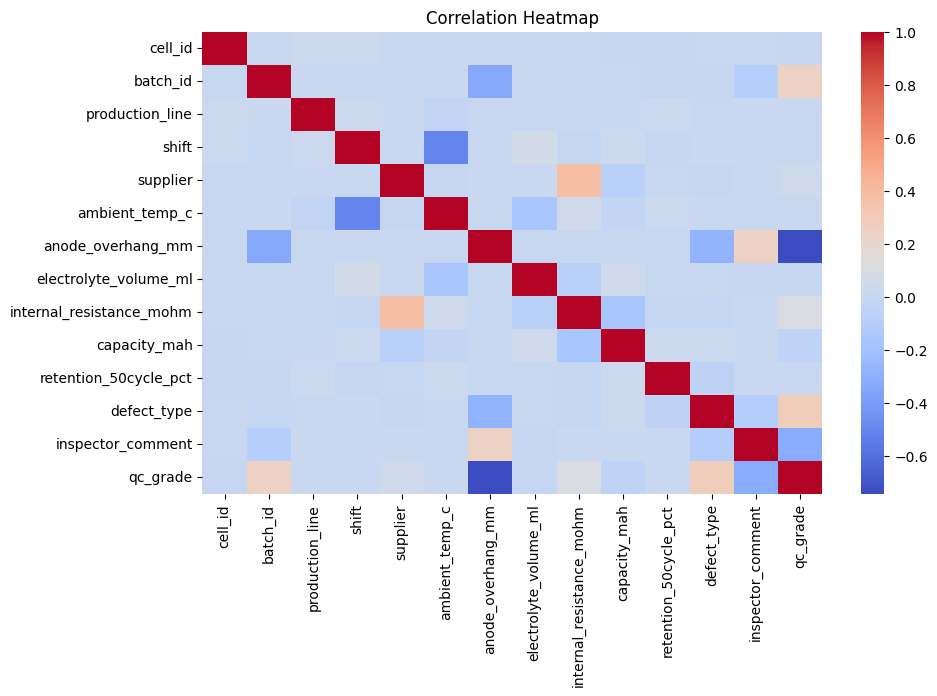

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [83]:
target_col = "qc_grade"

X = df.drop(target_col, axis=1)
y = df[target_col]

In [84]:
corr = df.corr()

print(corr[target_col].sort_values(ascending=False))

qc_grade                    1.000000
defect_type                 0.283864
batch_id                    0.254392
internal_resistance_mohm    0.094700
supplier                    0.034356
ambient_temp_c              0.008188
shift                       0.002336
retention_50cycle_pct       0.001773
production_line            -0.000311
cell_id                    -0.009728
electrolyte_volume_ml      -0.020563
capacity_mah               -0.052888
inspector_comment          -0.327663
anode_overhang_mm          -0.743146
Name: qc_grade, dtype: float64


In [85]:
X = X.drop("inspector_comment", axis=1)

Download cleaned Dataset

In [86]:
df.to_csv('cleaned_data.csv', index=False)

BOXPLOT (OUTLIER VISUALIZATION)

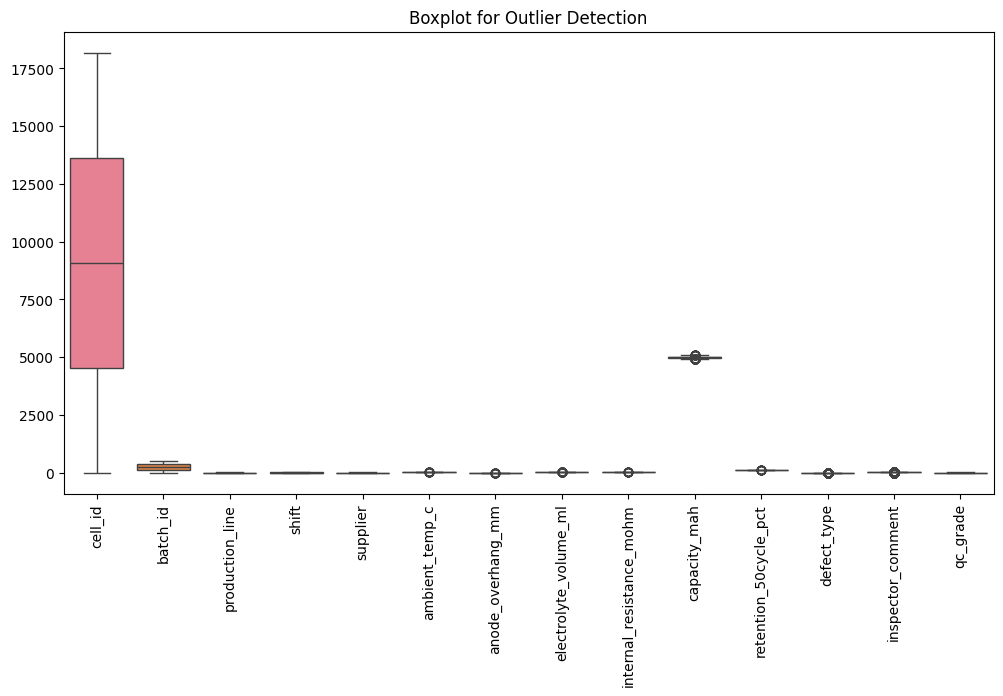

In [87]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42   # 🔥 more test data
)

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
df = df.sample(frac=1, random_state=42)

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#  Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features='sqrt',
    random_state=42
)

# Train
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred_dt)
prec = precision_score(y_test, y_pred_dt, average='weighted')
rec = recall_score(y_test, y_pred_dt, average='weighted')
f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("\nDecision Tree")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


Decision Tree
Accuracy: 0.8917517674783975
Precision: 0.8966890081574288
Recall: 0.8917517674783975
F1 Score: 0.8909632588735769


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model = LogisticRegression(
    max_iter=2000,
    C=0.5,
    solver='lbfgs',
    multi_class='auto'
)

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))


Logistic Regression
Accuracy: 0.9277297721916732
Precision: 0.9245947812807809
Recall: 0.9277297721916732
F1 Score: 0.9247810982172405


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features='log2',
    bootstrap=True,
    max_samples=0.7,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest (Controlled)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))


Random Forest (Controlled)
Accuracy: 0.997643362136685
Precision: 0.9976848035996976
Recall: 0.997643362136685
F1 Score: 0.9976521262088162


In [94]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear',   # 🔥 simpler model
    C=0.5              # 🔥 regularization
)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))


SVM
Accuracy: 0.9443833464257659
Precision: 0.9429947313245077
Recall: 0.9443833464257659
F1 Score: 0.9432591254174809


CORRELATION HEATMAP

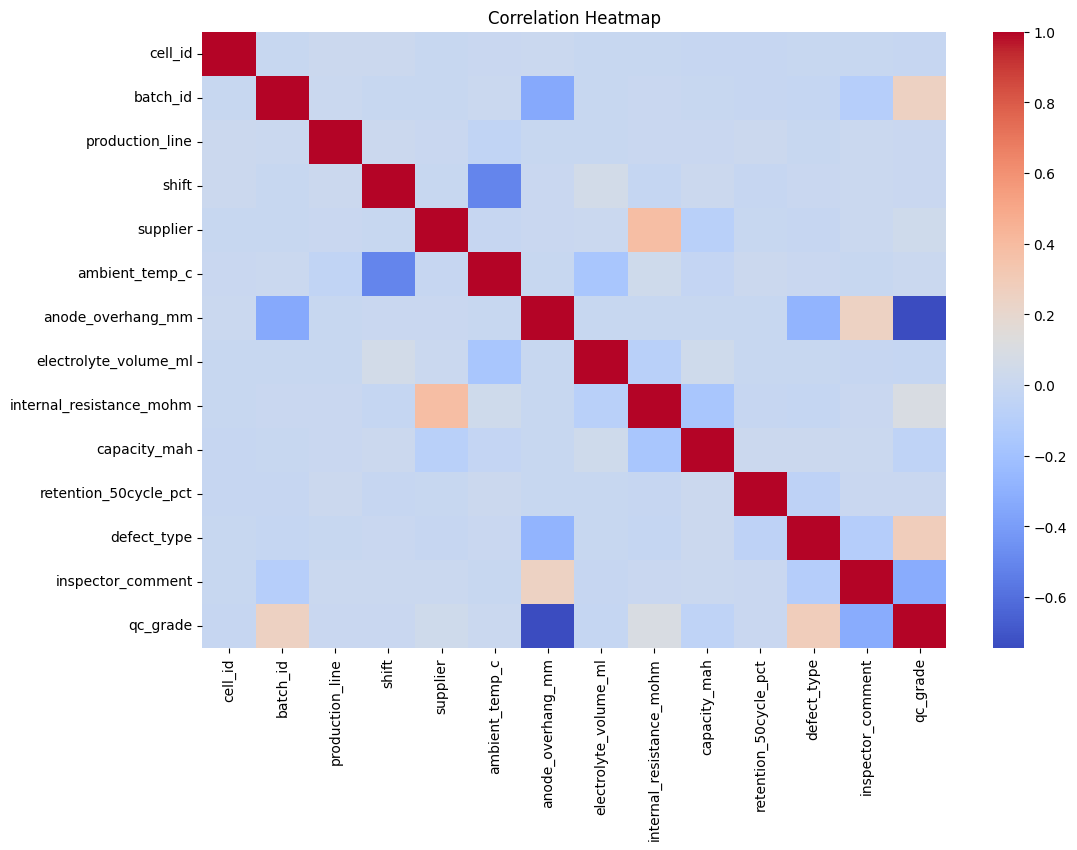

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

TARGET VARIABLE DISTRIBUTION (QC_Grade)

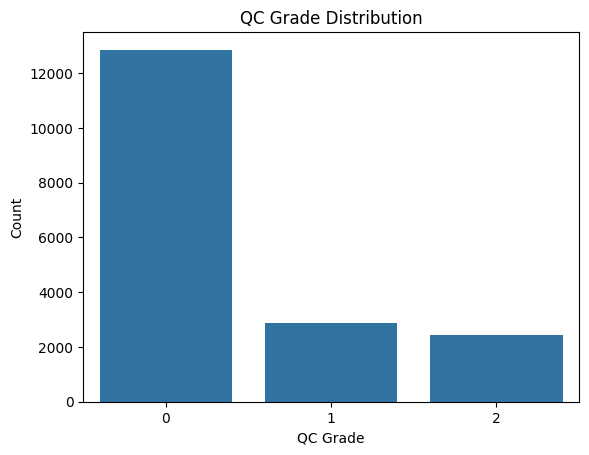

In [96]:
sns.countplot(x=y)
plt.title("QC Grade Distribution")
plt.xlabel("QC Grade")
plt.ylabel("Count")
plt.show()

Confusion Matrix - Logistic Regression

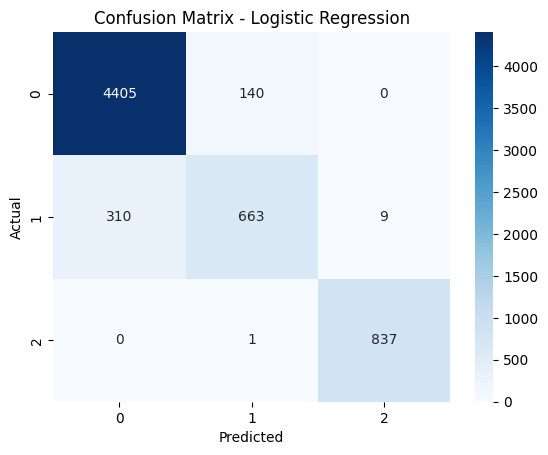

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix - Decision Tree

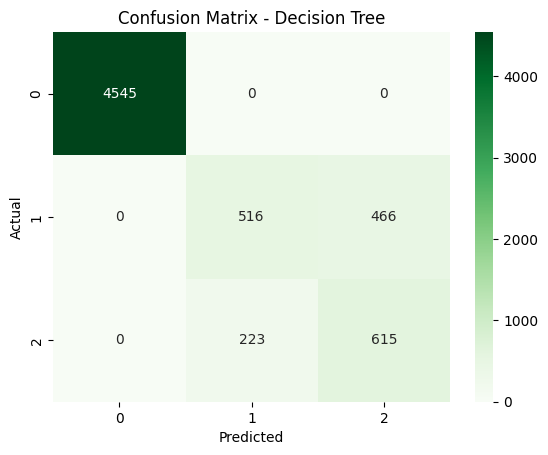

In [98]:

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix- Random Forest

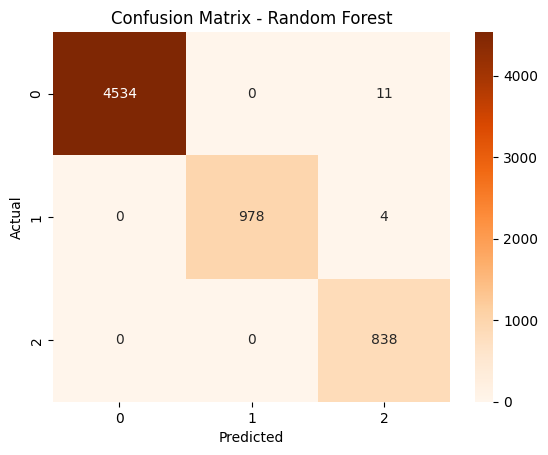

In [99]:

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix - SVM

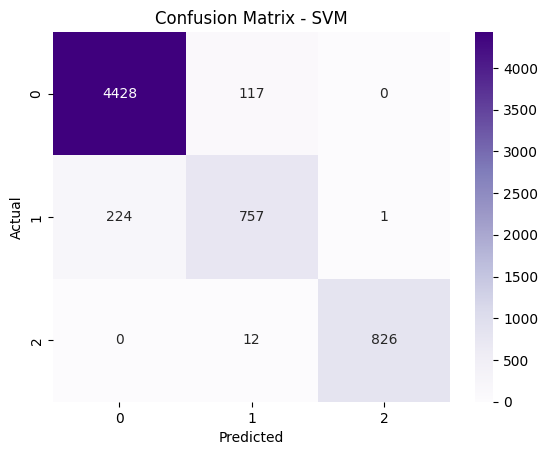

In [100]:
# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [101]:
from sklearn.preprocessing import label_binarize

# Adjust classes if needed
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

ROC Curve- Logistic Regression

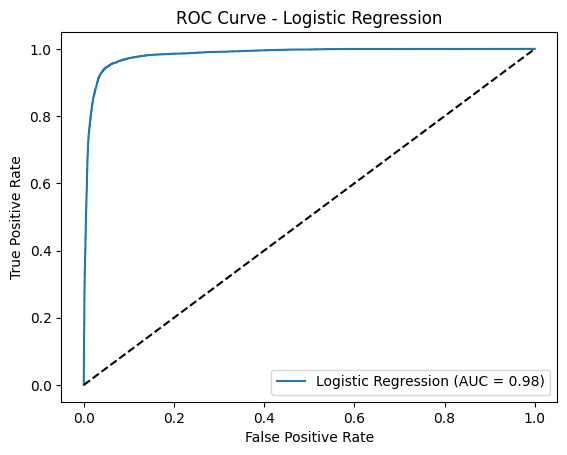

In [102]:
from sklearn.metrics import roc_curve, auc

y_score_lr = lr_model.predict_proba(X_test)

fpr_lr, tpr_lr, _ = roc_curve(y_test_bin.ravel(), y_score_lr.ravel())
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

ROC Curve- Decision Tree

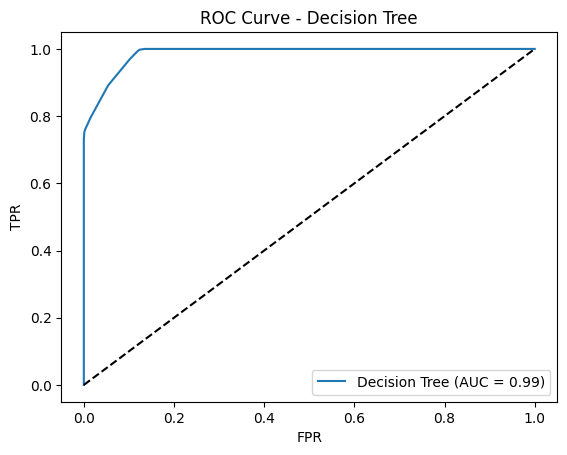

In [103]:
y_score_dt = dt_model.predict_proba(X_test)

fpr_dt, tpr_dt, _ = roc_curve(y_test_bin.ravel(), y_score_dt.ravel())
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

ROC Curve -Random Forest

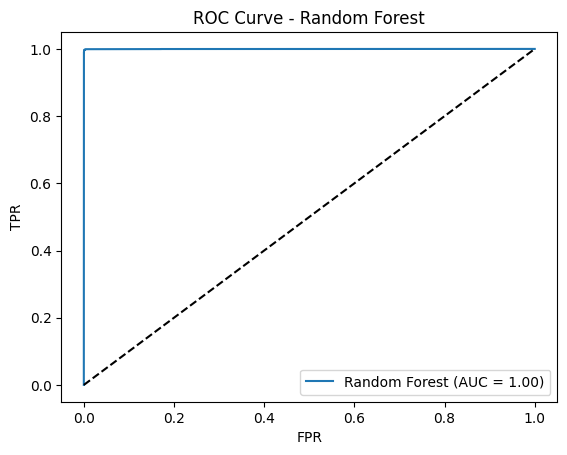

In [104]:
y_score_rf = rf_model.predict_proba(X_test)

fpr_rf, tpr_rf, _ = roc_curve(y_test_bin.ravel(), y_score_rf.ravel())
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

ROC Curve-SVM

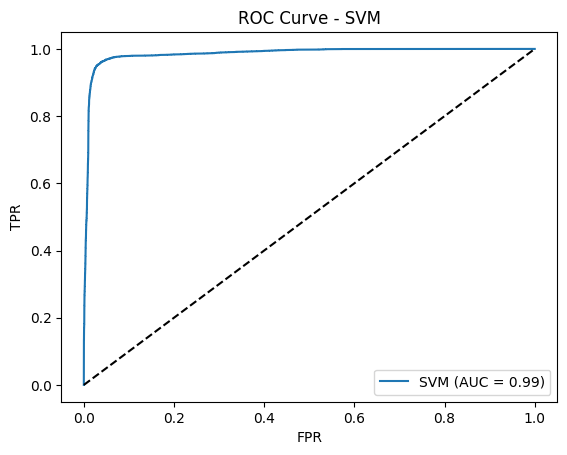

In [105]:
# redefine SVM if not done earlier
svm_model = SVC(kernel='linear', C=0.5, probability=True)
svm_model.fit(X_train, y_train)

y_score_svm = svm_model.predict_proba(X_test)

fpr_svm, tpr_svm, _ = roc_curve(y_test_bin.ravel(), y_score_svm.ravel())
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {roc_auc_svm:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [106]:
model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]

precisions = [
    precision_score(y_test, y_pred_lr, average='weighted'),
    precision_score(y_test, y_pred_dt, average='weighted'),
    precision_score(y_test, y_pred_rf, average='weighted'),
    precision_score(y_test, y_pred_svm, average='weighted')
]

recalls = [
    recall_score(y_test, y_pred_lr, average='weighted'),
    recall_score(y_test, y_pred_dt, average='weighted'),
    recall_score(y_test, y_pred_rf, average='weighted'),
    recall_score(y_test, y_pred_svm, average='weighted')
]

f1_scores = [
    f1_score(y_test, y_pred_lr, average='weighted'),
    f1_score(y_test, y_pred_dt, average='weighted'),
    f1_score(y_test, y_pred_rf, average='weighted'),
    f1_score(y_test, y_pred_svm, average='weighted')
]

MODEL COMPARISON BAR CHART

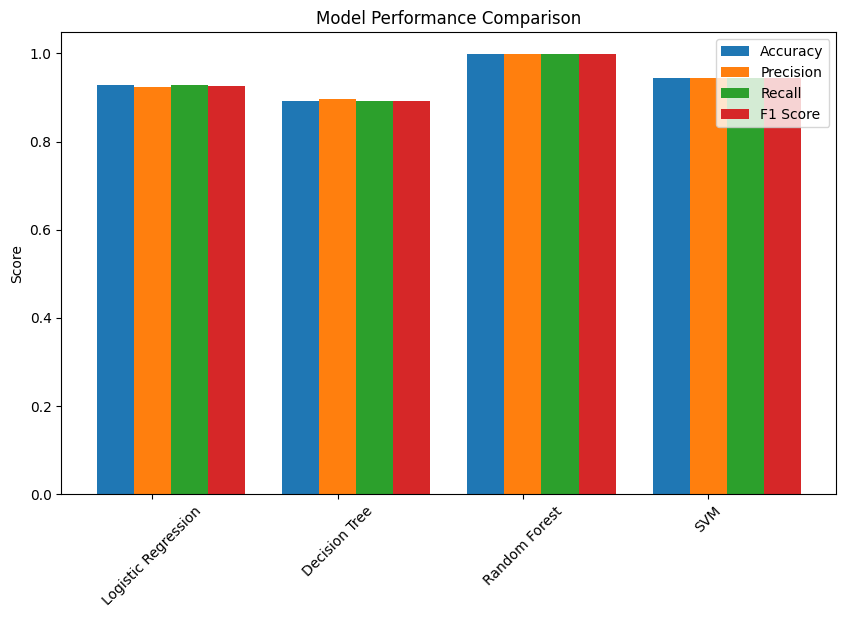

In [107]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(model_names))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - width, accuracies, width, label='Accuracy')
plt.bar(x, precisions, width, label='Precision')
plt.bar(x + width, recalls, width, label='Recall')
plt.bar(x + 2*width, f1_scores, width, label='F1 Score')

plt.xticks(x, model_names, rotation=45)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

FEATURE VS QC Grade

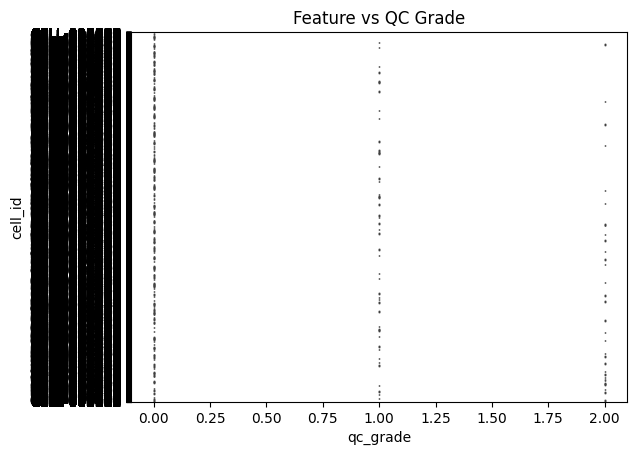

In [66]:
sns.boxplot(x=y, y=df.iloc[:,0])
plt.title("Feature vs QC Grade")
plt.show()

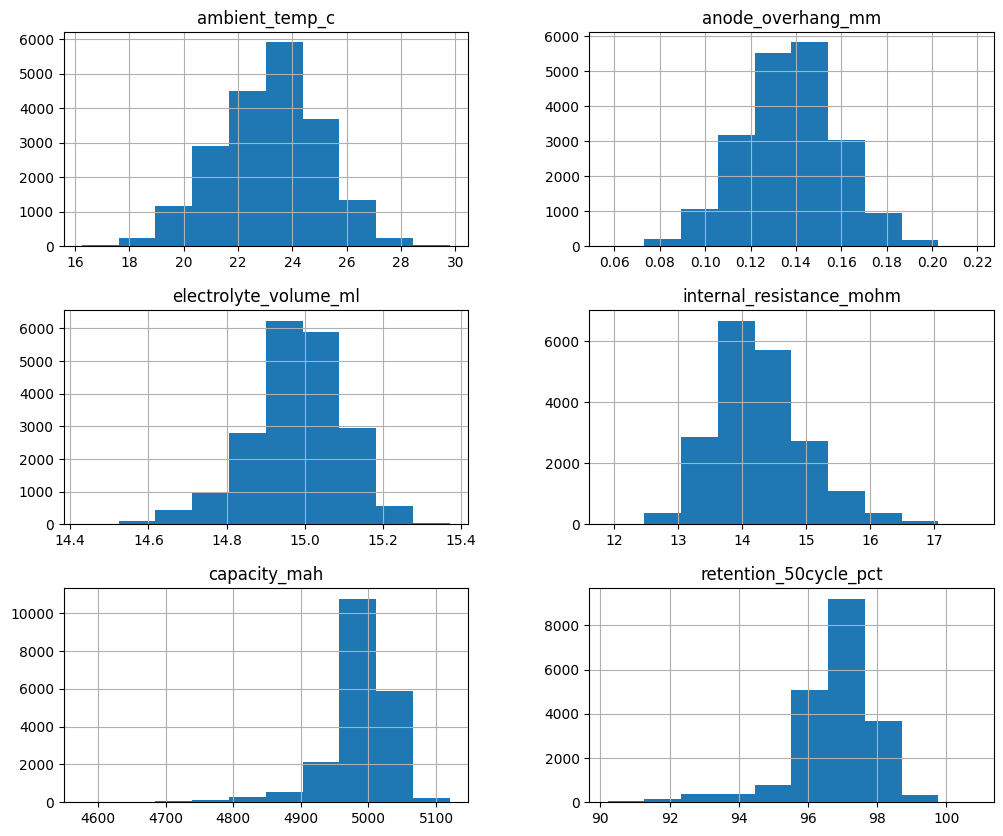

In [67]:
df.hist(figsize=(12,10))
plt.show()